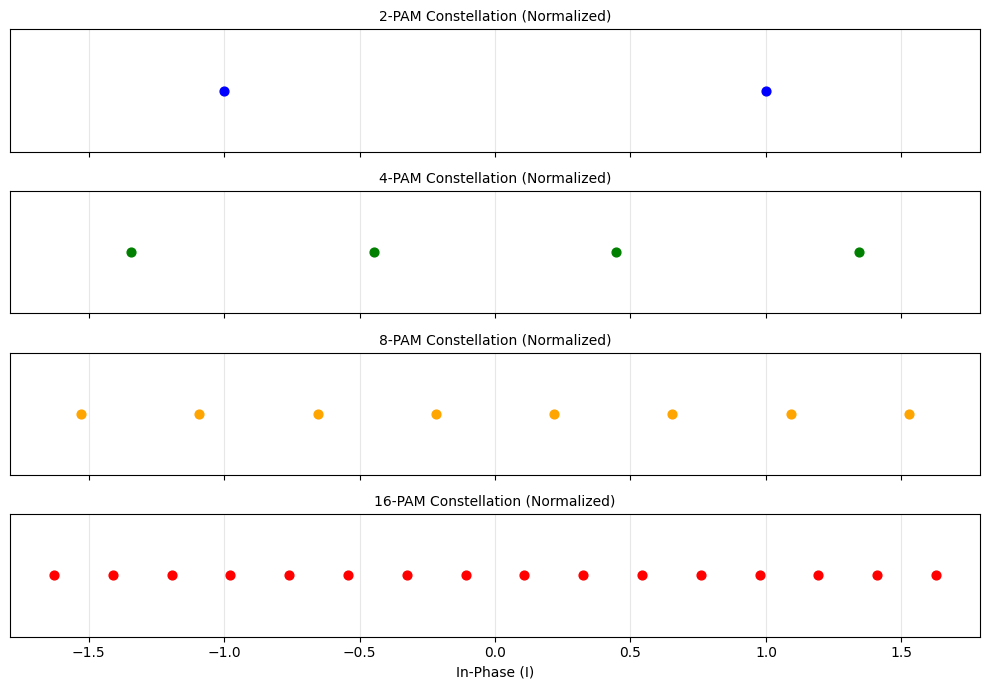

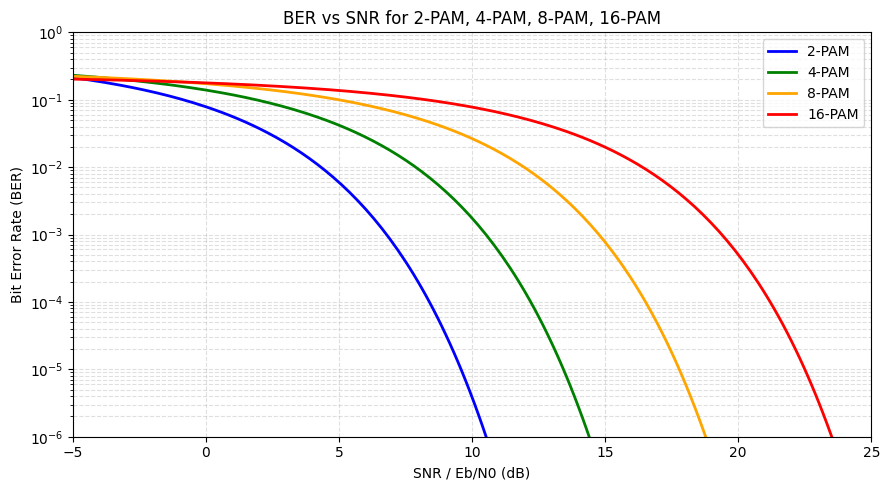

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

# Theoretical BER for M-PAM over AWGN
# Pe_symbol = 2 * (1 - 1/M) * Q( sqrt( (6 * log2(M) / (M^2 - 1)) * (Eb/N0) ) )
# With Gray coding: BER ≈ Pe_symbol / log2(M)
def ber_pam(M, snr_db):
    snr_lin = 10.0 ** (snr_db / 10.0)
    k = np.log2(M)
    d_term = np.sqrt((6.0 * k / (M**2 - 1.0)) * snr_lin)
    q_func = 0.5 * erfc(d_term / np.sqrt(2.0))
    ser = 2.0 * (1.0 - 1.0 / M) * q_func
    return ser / k

# Constellation alphabets: -(M-1), ..., -1, 1, ..., (M-1) normalized to unit power
def get_pam_constellation(M):
    points = np.arange(-(M - 1), M, 2, dtype=float)
    return points / np.sqrt(np.mean(points**2))

pam_orders = [2, 4, 8, 16]
colors = ['blue', 'green', 'orange', 'red']
snr_db_range = np.linspace(-5, 25, 200)

# 1. Plot Constellations
fig, axes = plt.subplots(4, 1, figsize=(10, 7), sharex=True)
for idx, (M, col) in enumerate(zip(pam_orders, colors)):
    pts = get_pam_constellation(M)
    axes[idx].scatter(pts, np.zeros_like(pts), color=col, s=40, zorder=3)
    axes[idx].set_title(f'{M}-PAM Constellation (Normalized)', fontsize=10)
    axes[idx].set_yticks([])
    axes[idx].set_ylim(-0.5, 0.5)
    axes[idx].grid(True, alpha=0.3)
axes[-1].set_xlabel('In-Phase (I)')
plt.tight_layout()
plt.show()

# 2. Plot BER vs SNR
plt.figure(figsize=(9, 5))
for M, col in zip(pam_orders, colors):
    plt.semilogy(snr_db_range, ber_pam(M, snr_db_range), label=f'{M}-PAM', color=col, lw=2)

plt.title('BER vs SNR for 2-PAM, 4-PAM, 8-PAM, 16-PAM')
plt.xlabel('SNR / Eb/N0 (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.ylim(1e-6, 1.0)
plt.xlim(-5, 25)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

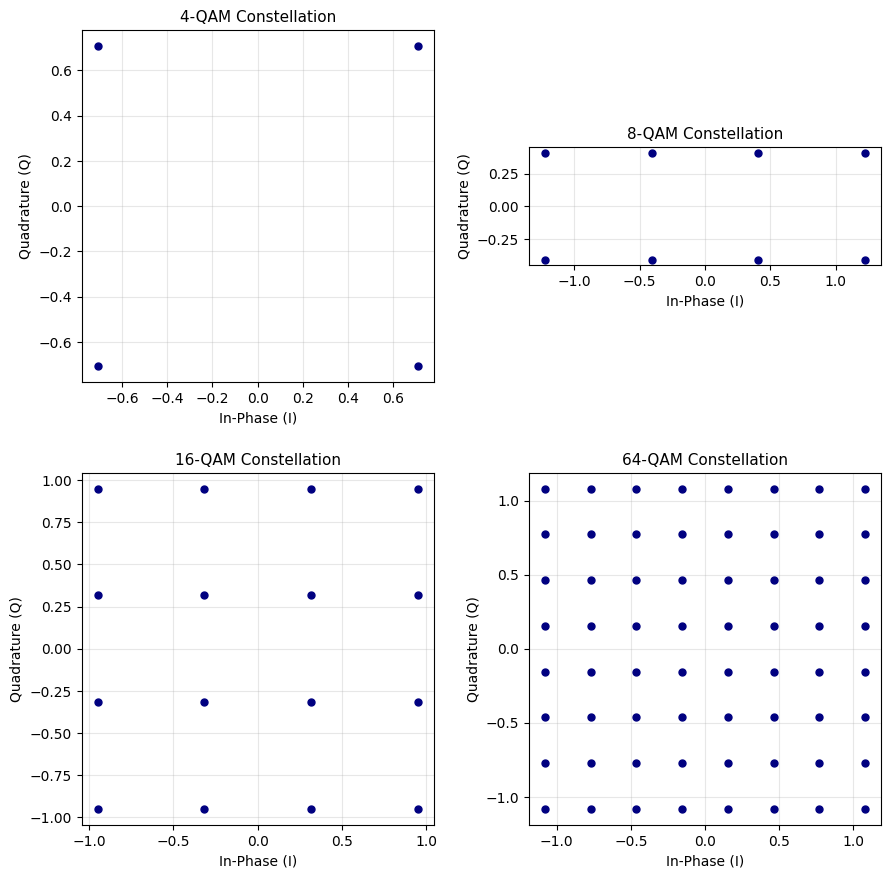

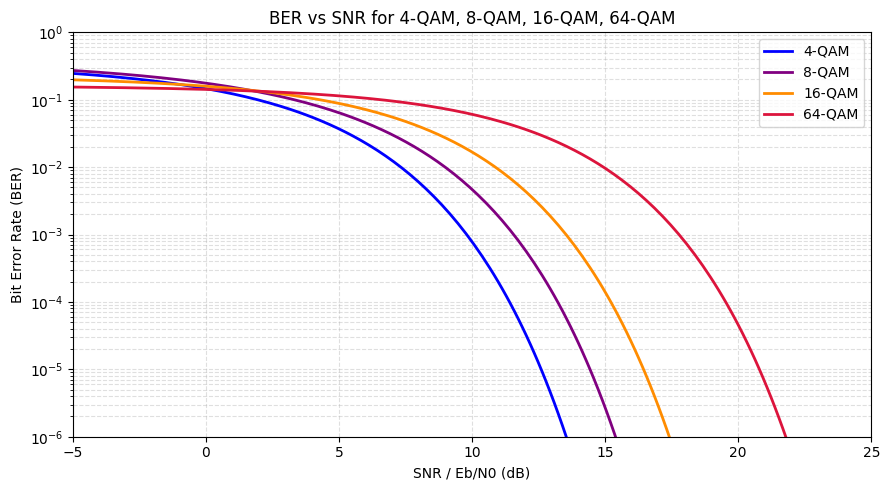

In [2]:
# Helper to build square QAM constellations
def get_qam_constellation(M):
    if M == 4:
        vals = np.array([-1, 1])
        grid = np.array([x + 1j * y for x in vals for y in vals])
    elif M == 8:
        # Cross constellation (8 points)
        grid = np.array([-3-1j, -3+1j, -1-1j, -1+1j, 1-1j, 1+1j, 3-1j, 3+1j])
    elif M == 16:
        vals = np.array([-3, -1, 1, 3])
        grid = np.array([x + 1j * y for x in vals for y in vals])
    elif M == 64:
        vals = np.array([-7, -5, -3, -1, 1, 3, 5, 7])
        grid = np.array([x + 1j * y for x in vals for y in vals])
    # Normalize constellation to average power = 1
    return grid / np.sqrt(np.mean(np.abs(grid)**2))

# Theoretical BER calculation for rectangular/square QAM
def ber_qam(M, snr_db):
    snr_lin = 10.0 ** (snr_db / 10.0)
    k = np.log2(M)
    if M in [4, 16, 64]:
        # Square QAM exact formula
        arg = np.sqrt((3.0 * k / (2.0 * (M - 1.0))) * snr_lin)
        q_term = 0.5 * erfc(arg / np.sqrt(2.0))
        ser = 4.0 * (1.0 - 1.0 / np.sqrt(M)) * q_term - 4.0 * ((1.0 - 1.0 / np.sqrt(M))**2) * (q_term**2)
        return ser / k
    elif M == 8:
        # Standard nearest-neighbor union bound approximation for 8-QAM
        arg = np.sqrt(1.5 * (k / 7.0) * snr_lin)
        q_term = 0.5 * erfc(arg / np.sqrt(2.0))
        return (5.0 / 2.0) * q_term / k

qam_orders = [4, 8, 16, 64]
fig, axes = plt.subplots(2, 2, figsize=(9, 9))
axes = axes.ravel()

# 1. Plot Constellations
for idx, M in enumerate(qam_orders):
    const = get_qam_constellation(M)
    axes[idx].scatter(np.real(const), np.imag(const), color='navy', s=25)
    axes[idx].set_title(f'{M}-QAM Constellation', fontsize=11)
    axes[idx].set_xlabel('In-Phase (I)')
    axes[idx].set_ylabel('Quadrature (Q)')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_aspect('equal')
plt.tight_layout()
plt.show()

# 2. Plot BER vs SNR
plt.figure(figsize=(9, 5))
snr_qam = np.linspace(-5, 25, 200)
qam_colors = ['blue', 'purple', 'darkorange', 'crimson']

for M, col in zip(qam_orders, qam_colors):
    plt.semilogy(snr_qam, ber_qam(M, snr_qam), label=f'{M}-QAM', color=col, lw=2)

plt.title('BER vs SNR for 4-QAM, 8-QAM, 16-QAM, 64-QAM')
plt.xlabel('SNR / Eb/N0 (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.ylim(1e-6, 1.0)
plt.xlim(-5, 25)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

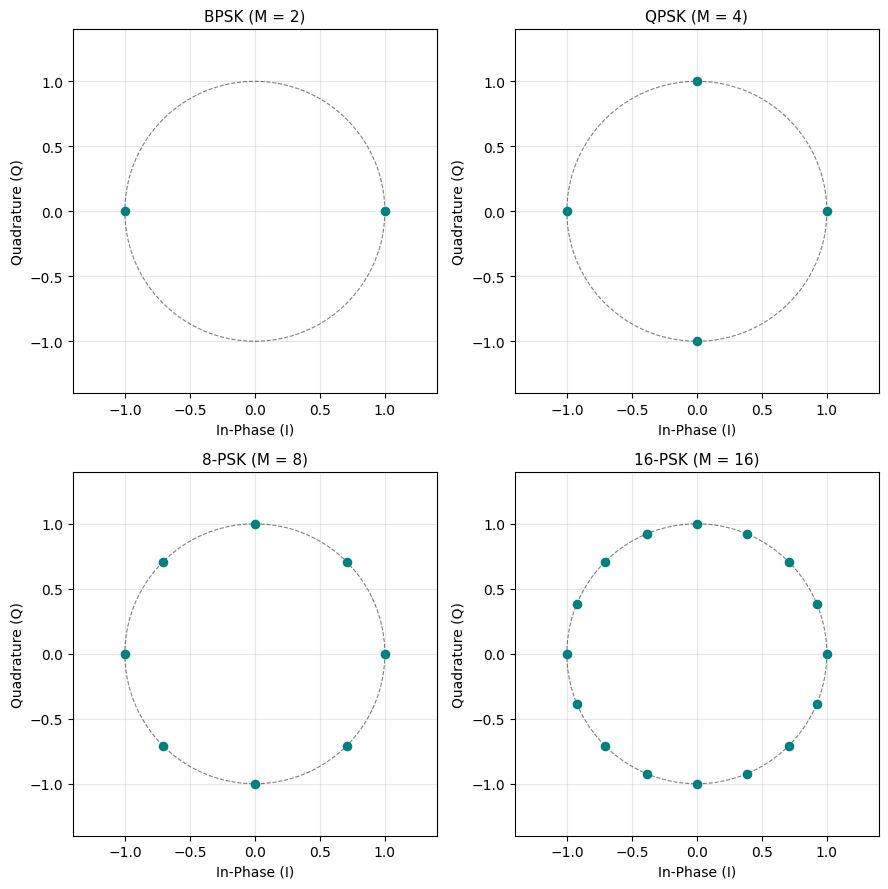

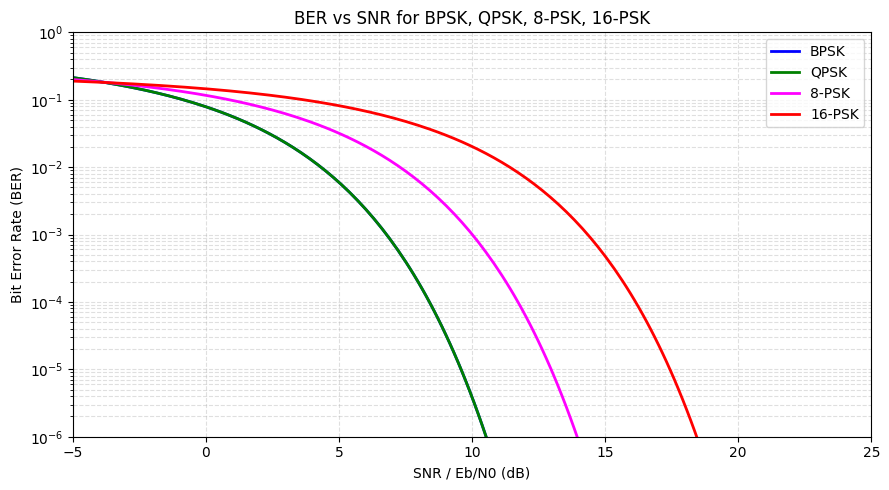

In [3]:
# Constellation points on the complex unit circle
def get_psk_constellation(M):
    indices = np.arange(M)
    return np.exp(1j * (2.0 * np.pi * indices / M))

# Theoretical BER for M-PSK
def ber_psk(M, snr_db):
    snr_lin = 10.0 ** (snr_db / 10.0)
    if M == 2:
        # BPSK exact
        return 0.5 * erfc(np.sqrt(snr_lin))
    elif M == 4:
        # QPSK exact (identical to BPSK in Eb/N0)
        return 0.5 * erfc(np.sqrt(snr_lin))
    else:
        # Higher order M-PSK Gray-coded approximation
        k = np.log2(M)
        arg = np.sqrt(2.0 * k * snr_lin) * np.sin(np.pi / M)
        q_term = 0.5 * erfc(arg / np.sqrt(2.0))
        ser = 2.0 * q_term
        return ser / k

psk_orders = [2, 4, 8, 16]
psk_names = ['BPSK', 'QPSK', '8-PSK', '16-PSK']
psk_colors = ['blue', 'green', 'magenta', 'red']

# 1. Plot Constellations
fig, axes = plt.subplots(2, 2, figsize=(9, 9))
axes = axes.ravel()

theta_circle = np.linspace(0, 2*np.pi, 200)

for idx, (M, name) in enumerate(zip(psk_orders, psk_names)):
    pts = get_psk_constellation(M)
    axes[idx].plot(np.cos(theta_circle), np.sin(theta_circle), 'k--', lw=0.8, alpha=0.5)
    axes[idx].scatter(np.real(pts), np.imag(pts), color='teal', s=35, zorder=3)
    axes[idx].set_title(f'{name} (M = {M})', fontsize=11)
    axes[idx].set_xlabel('In-Phase (I)')
    axes[idx].set_ylabel('Quadrature (Q)')
    axes[idx].set_xlim(-1.4, 1.4)
    axes[idx].set_ylim(-1.4, 1.4)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_aspect('equal')
plt.tight_layout()
plt.show()

# 2. Plot BER vs SNR
plt.figure(figsize=(9, 5))
snr_psk = np.linspace(-5, 25, 200)

for M, name, col in zip(psk_orders, psk_names, psk_colors):
    plt.semilogy(snr_psk, ber_psk(M, snr_psk), label=name, color=col, lw=2)

plt.title('BER vs SNR for BPSK, QPSK, 8-PSK, 16-PSK')
plt.xlabel('SNR / Eb/N0 (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.ylim(1e-6, 1.0)
plt.xlim(-5, 25)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()